# Colab 3 — Proposed method and benchmark models

This notebook implements the empirical evaluation pipeline of the article.

## Objectives
1. Load the analytical cohort produced in Colab 1.
2. Define hospital-aware validation splits.
3. Implement benchmark methods:
   - age-only heuristic;
   - age + maintenance heuristic;
   - logistic regression;
   - gradient boosting / XGBoost-style tabular learner.
4. Provide a practical scaffold for the proposed hierarchical Bayesian latent deterioration decision method.
5. Compute predictive, ranking, and decision-oriented metrics.
6. Prepare outputs for the results section of the manuscript.

## Important note
This notebook is intentionally organized in two layers:

- **Fully executable baseline layer:** heuristics and standard predictive models;
- **Method-development layer:** a structured scaffold for the proposed Bayesian latent deterioration method.

This design allows the article to progress even if the final Bayesian implementation requires several rounds of refinement.

In [31]:
# ============================================================
# 1) Imports and configuration
# ============================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve
)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 220)

DATA_PATH = "analytic_cohort_for_modeling.csv"

# Set to True only after confirming that PyMC is available in the Colab runtime
RUN_BAYESIAN_MODEL = False

In [ ]:
# ============================================================
# 2) Load analytical cohort
# ============================================================
df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
display(df.head())
print(df.dtypes)

Shape: (14809, 41)


,equip_hash,hospital_hash,year,age_at_year,cm_count,total_downtime_hours,positive_downtime_count,max_downtime,any_downtime,brand_hash,model_hash,LEITOS_EXISTENTES_z,LEITOS_SUS_z,UTI_TOTAL_EXIST_z,UTI_TOTAL_SUS_z,UTI_ADULTO_EXIST_z,UTI_ADULTO_SUS_z,UTI_PEDIATRICO_EXIST_z,UTI_PEDIATRICO_SUS_z,UTI_NEONATAL_EXIST_z,UTI_NEONATAL_SUS_z,log_cm_count,log_total_downtime,log_max_downtime,downtime_per_cm,log_downtime_per_cm,downtime_event_intensity,log_downtime_event_intensity,age_band,cm_count_lag1,total_downtime_lag1,any_downtime_lag1,age_lag1,cm_count_expanding_mean_lag1,downtime_expanding_mean_lag1,delta_cm_vs_lag1,delta_downtime_vs_lag1,cm_count_t_plus_1,downtime_t_plus_1,any_downtime_t_plus_1,high_downtime_t_plus_1
0,eq_00339a54eaa6,h_f3391264376f,2022,2.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.163034,1.173656,1.139074,0.934462,0.501098,0.560743,1.321094,1.321094,1.064779,1.121053,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
1,eq_00339a54eaa6,h_f3391264376f,2023,3.0,0.0,0.0,0.0,0.0,0,b_b5582bab280c,m_0f2cb0e1a162,1.189540,1.214732,1.015032,0.933842,-0.184465,-0.090361,1.275125,1.305313,1.105163,1.141548,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,1.0,186.0,1.0,1.0
2,eq_00339a54eaa6,h_f3391264376f,2024,4.0,1.0,186.0,1.0,186.0,1,b_b5582bab280c,m_0f2cb0e1a162,1.086737,1.125939,0.810040,0.865332,-0.289683,-0.150083,0.934306,1.132643,1.069034,1.079456,0.693147,5.231109,5.231109,185.999814,5.231108,185.999814,5.231108,<=5,0.0,0.0,0.0,3.0,0.0,0.0,1.0,186.0,1.0,27.0,1.0,0.0
3,eq_0044d3ea0082,h_b052b2239a62,2023,0.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_5e06c8e5a3cd,-0.467852,-0.376477,-1.022215,-0.729593,-0.184465,-0.090361,-0.893161,-0.890962,-1.504843,-1.480203,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,0.0,0.0,0.0
4,eq_0044d3ea0082,h_b052b2239a62,2024,1.0,0.0,0.0,0.0,0.0,0,b_293446a1fb5f,m_5e06c8e5a3cd,-0.527059,-0.450616,-1.230858,-0.886312,-0.289683,-0.150083,-1.210405,-1.014119,-1.539650,-1.534416,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,<=5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,1.0,0.0


equip_hash                       object
hospital_hash                    object
year                              int64
age_at_year                     float64
cm_count                        float64
total_downtime_hours            float64
positive_downtime_count         float64
max_downtime                    float64
any_downtime                      int64
brand_hash                       object
model_hash                       object
LEITOS_EXISTENTES_z             float64
LEITOS_SUS_z                    float64
UTI_TOTAL_EXIST_z               float64
UTI_TOTAL_SUS_z                 float64
UTI_ADULTO_EXIST_z              float64
UTI_ADULTO_SUS_z                float64
UTI_PEDIATRICO_EXIST_z          float64
UTI_PEDIATRICO_SUS_z            float64
UTI_NEONATAL_EXIST_z            float64
UTI_NEONATAL_SUS_z              float64
log_cm_count                    float64
log_total_downtime              float64
log_max_downtime                float64
downtime_per_cm                 float64


## Minimum required variables
The code below assumes that the analytical cohort contains at least:
- equipment identifier
- hospital identifier
- asset identifiers (brand/model)
- age
- current maintenance burden
- current downtime burden
- future binary outcome

In [50]:
# ============================================================
# 3) Basic checks
# ============================================================
required_cols = [
    "equip_hash",
    "hospital_hash",
    "brand_hash",
    "model_hash",
    "year",
    "age_at_year",
    "cm_count",
    "total_downtime_hours",
    "high_downtime_t_plus_1"
]

missing_required = [c for c in required_cols if c not in df.columns]
assert not missing_required, f"Missing columns: {missing_required}"

print("Hospitals:", df["hospital_hash"].nunique())
print("Equipment units:", df["equip_hash"].nunique())
print("Outcome rate:", df["high_downtime_t_plus_1"].mean())

Hospitals: 39
Equipment units: 5503
Outcome rate: 0.25045580390303196


# 4. Variable sets

The benchmark models use a shared feature set when possible, so that the comparison focuses on modeling assumptions rather than on arbitrary feature availability.

In [51]:
# ============================================================
# 4) Feature definition
# ============================================================
candidate_numeric = [
    "age_at_year",
    "cm_count",
    "total_downtime_hours",
    "positive_downtime_count",
    "max_downtime",
    "any_downtime",
    "log_cm_count",
    "log_total_downtime",
    "log_max_downtime",
    "downtime_per_cm",
    "log_downtime_per_cm",
    "downtime_event_intensity",
    "log_downtime_event_intensity",
    "cm_count_lag1",
    "total_downtime_lag1",
    "any_downtime_lag1",
    "age_lag1",
    "cm_count_expanding_mean_lag1",
    "downtime_expanding_mean_lag1",
    "delta_cm_vs_lag1",
    "delta_downtime_vs_lag1"
]

candidate_categorical = [
    "brand_hash",
    "model_hash"
]

hospital_context_cols = [
    c for c in df.columns
    if c.endswith("_z") or c.startswith("ctx_")
]

numeric_features = [c for c in candidate_numeric + hospital_context_cols if c in df.columns]
categorical_features = [c for c in candidate_categorical if c in df.columns]

target_col = "high_downtime_t_plus_1"

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['age_at_year', 'cm_count', 'total_downtime_hours', 'positive_downtime_count', 'max_downtime', 'any_downtime', 'log_cm_count', 'log_total_downtime', 'log_max_downtime', 'downtime_per_cm', 'log_downtime_per_cm', 'downtime_event_intensity', 'log_downtime_event_intensity', 'cm_count_lag1', 'total_downtime_lag1', 'any_downtime_lag1', 'age_lag1', 'cm_count_expanding_mean_lag1', 'downtime_expanding_mean_lag1', 'delta_cm_vs_lag1', 'delta_downtime_vs_lag1', 'LEITOS_EXISTENTES_z', 'LEITOS_SUS_z', 'UTI_TOTAL_EXIST_z', 'UTI_TOTAL_SUS_z', 'UTI_ADULTO_EXIST_z', 'UTI_ADULTO_SUS_z', 'UTI_PEDIATRICO_EXIST_z', 'UTI_PEDIATRICO_SUS_z', 'UTI_NEONATAL_EXIST_z', 'UTI_NEONATAL_SUS_z']
Categorical features: ['brand_hash', 'model_hash']


# 5. Hospital-aware validation design

Because the paper is explicitly concerned with cross-hospital transportability, evaluation should respect hospital boundaries.

In [52]:
# ============================================================
# 5) Hospital-aware holdout split
# ============================================================
hospital_stats = (
    df.groupby("hospital_hash")
      .agg(
          n=("equip_hash", "size"),
          outcome_rate=(target_col, "mean")
      )
      .reset_index()
      .sort_values("n", ascending=False)
)

display(hospital_stats.head(10))

total_rows = len(df)
test_target = int(total_rows * 0.20)

test_hospitals = []
running = 0
for _, row in hospital_stats.iterrows():
    if running < test_target:
        test_hospitals.append(row["hospital_hash"])
        running += int(row["n"])

train_df = df[~df["hospital_hash"].isin(test_hospitals)].copy()
test_df = df[df["hospital_hash"].isin(test_hospitals)].copy()

print("Train hospitals:", train_df["hospital_hash"].nunique())
print("Test hospitals:", test_df["hospital_hash"].nunique())
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("Train outcome rate:", train_df[target_col].mean())
print("Test outcome rate:", test_df[target_col].mean())

,hospital_hash,n,outcome_rate
9,h_31b6b276b9e0,1119,0.248436
33,h_e176ae8ff561,975,0.200000
19,h_9e0082cc03bb,897,0.122631
37,h_f3391264376f,735,0.187755
38,h_fc448b9753aa,700,0.128571
32,h_db26b7f2fbc8,650,0.312308
23,h_b052b2239a62,649,0.315871
36,h_ed200b674eda,638,0.101881
29,h_d90e01eb9931,629,0.494436
3,h_12dcdfb79130,492,0.382114


Train hospitals: 36
Test hospitals: 3
Train shape: (11818, 41)
Test shape: (2991, 41)
Train outcome rate: 0.26451176171941104
Test outcome rate: 0.1949180875961217


# 6. Utility functions

In [53]:
# ============================================================
# 6) Evaluation utilities
# ============================================================
def top_k_capture_rate(y_true, scores, k_ratio=0.10):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)
    k = max(1, int(len(scores) * k_ratio))
    idx = np.argsort(-scores)[:k]
    positives_total = y_true.sum()
    if positives_total == 0:
        return np.nan
    return y_true[idx].sum() / positives_total

def classification_summary(y_true, scores, name, k_ratio=0.10):
    scores = np.asarray(scores)
    return {
        "model": name,
        "auroc": roc_auc_score(y_true, scores),
        "auprc": average_precision_score(y_true, scores),
        "brier": brier_score_loss(y_true, scores),
        "top10_capture": top_k_capture_rate(y_true, scores, k_ratio=k_ratio)
    }

def standardize_series(s):
    s = pd.Series(s)
    std = s.std()
    if pd.isna(std) or std == 0:
        return pd.Series(np.zeros(len(s)), index=s.index)
    return (s - s.mean()) / std

# 7. Benchmark 1 — Age-only heuristic

In [54]:
# ============================================================
# 7) Age-only heuristic
# ============================================================
age_score_raw = standardize_series(test_df["age_at_year"])

# Scale the raw scores to be between 0 and 1
min_val = age_score_raw.min()
max_val = age_score_raw.max()

# Handle cases where min_val == max_val to avoid division by zero
if min_val == max_val:
    # If all values are the same, assign a neutral probability (e.g., 0.5)
    age_score_test = np.full_like(age_score_raw, 0.5).values
else:
    age_score_test = ((age_score_raw - min_val) / (max_val - min_val)).values

age_results = classification_summary(
    y_true=test_df[target_col].values,
    scores=age_score_test,
    name="Age-only heuristic"
)

age_results

{'model': 'Age-only heuristic',
 'auroc': np.float64(0.6296065715767338),
 'auprc': np.float64(0.2840805030100829),
 'brier': np.float64(0.1654117444927375),
 'top10_capture': np.float64(0.1835334476843911)}

# 8. Benchmark 2 — Age + maintenance heuristic

In [55]:
# ============================================================
# 8) Age + maintenance heuristic
# ============================================================
test_age_z = standardize_series(test_df["age_at_year"])
test_cm_z = standardize_series(test_df["cm_count"])
test_dt_z = standardize_series(test_df["total_downtime_hours"])

score_am_raw = (test_age_z + test_cm_z + test_dt_z) / 3

# Scale the raw scores to be between 0 and 1
min_val = score_am_raw.min()
max_val = score_am_raw.max()

# Handle cases where min_val == max_val to avoid division by zero
if min_val == max_val:
    score_am_test = np.full_like(score_am_raw, 0.5).values
else:
    score_am_test = ((score_am_raw - min_val) / (max_val - min_val)).values

am_results = classification_summary(
    y_true=test_df[target_col].values,
    scores=score_am_test,
    name="Age + maintenance heuristic"
)

am_results

{'model': 'Age + maintenance heuristic',
 'auroc': np.float64(0.6741924431426405),
 'auprc': np.float64(0.32237313148835556),
 'brier': np.float64(0.16527984681815389),
 'top10_capture': np.float64(0.22641509433962265)}

# 9. Benchmark 3 — Logistic regression

In [56]:
# ============================================================
# 9) Logistic regression baseline
# ============================================================
X_train = train_df[numeric_features + categorical_features].copy()
y_train = train_df[target_col].astype(int).values

X_test = test_df[numeric_features + categorical_features].copy()
y_test = test_df[target_col].astype(int).values

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

logit_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logit_model.fit(X_train, y_train)
logit_scores_test = logit_model.predict_proba(X_test)[:, 1]

logit_results = classification_summary(
    y_true=y_test,
    scores=logit_scores_test,
    name="Logistic regression"
)

logit_results

{'model': 'Logistic regression',
 'auroc': np.float64(0.6467189841751053),
 'auprc': np.float64(0.3421088190846381),
 'brier': np.float64(0.19182205676363462),
 'top10_capture': np.float64(0.2332761578044597)}

# 10. Benchmark 4 — Gradient boosting baseline

A strong nonlinear tabular baseline is included.  
To keep the notebook portable, `HistGradientBoostingClassifier` is used by default.

In [57]:
# ============================================================
# 10) Gradient boosting baseline
# ============================================================
gb_numeric_features = numeric_features.copy()

X_train_gb = train_df[gb_numeric_features].copy()
X_test_gb = test_df[gb_numeric_features].copy()

gb_preprocessor = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

X_train_gb_proc = gb_preprocessor.fit_transform(X_train_gb)
X_test_gb_proc = gb_preprocessor.transform(X_test_gb)

gb_model = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=6,
    max_iter=300,
    random_state=42
)

gb_model.fit(X_train_gb_proc, y_train)
gb_scores_test = gb_model.predict_proba(X_test_gb_proc)[:, 1]

gb_results = classification_summary(
    y_true=y_test,
    scores=gb_scores_test,
    name="Gradient boosting"
)

gb_results

{'model': 'Gradient boosting',
 'auroc': np.float64(0.5376770826803736),
 'auprc': np.float64(0.23949458903104115),
 'brier': np.float64(0.16168647556139729),
 'top10_capture': np.float64(0.1269296740994854)}

# 11. Comparative predictive summary

In [58]:
# ============================================================
# 11) Summary table
# ============================================================
results_df = pd.DataFrame([
    age_results,
    am_results,
    logit_results,
    gb_results
]).sort_values("auprc", ascending=False)

display(results_df)

,model,auroc,auprc,brier,top10_capture
2,Logistic regression,0.646719,0.342109,0.191822,0.233276
1,Age + maintenance heuristic,0.674192,0.322373,0.165280,0.226415
0,Age-only heuristic,0.629607,0.284081,0.165412,0.183533
3,Gradient boosting,0.537677,0.239495,0.161686,0.126930


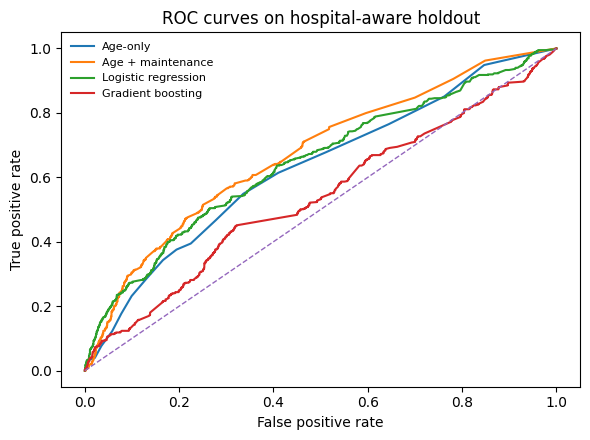

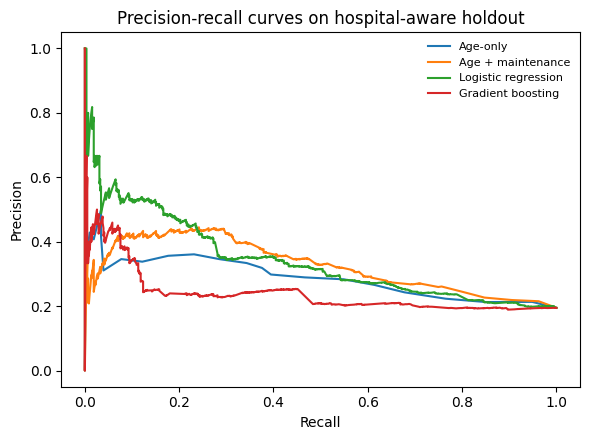

In [59]:
# ============================================================
# 12) ROC and PR comparison
# ============================================================
score_dict = {
    "Age-only": age_score_test,
    "Age + maintenance": score_am_test,
    "Logistic regression": logit_scores_test,
    "Gradient boosting": gb_scores_test
}

plt.figure(figsize=(6, 4.5))
for name, scores in score_dict.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on hospital-aware holdout")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
for name, scores in score_dict.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    plt.plot(recall, precision, label=name)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves on hospital-aware holdout")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

# 12. Decision-oriented benchmark: simple risk-threshold rule

This block converts predicted probabilities into replacement decisions.

In [60]:
# ============================================================
# 13) Simple risk-threshold decision rule
# ============================================================
def threshold_actions(scores, threshold=0.5):
    return np.where(np.asarray(scores) >= threshold, "replace", "keep")

threshold = 0.5
test_df_decision = test_df.copy()
test_df_decision["risk_logit"] = logit_scores_test
test_df_decision["risk_gb"] = gb_scores_test

test_df_decision["action_logit_thr"] = threshold_actions(test_df_decision["risk_logit"], threshold)
test_df_decision["action_gb_thr"] = threshold_actions(test_df_decision["risk_gb"], threshold)

display(test_df_decision[[
    "equip_hash", "hospital_hash", target_col,
    "risk_logit", "action_logit_thr",
    "risk_gb", "action_gb_thr"
]].head())

,equip_hash,hospital_hash,high_downtime_t_plus_1,risk_logit,action_logit_thr,risk_gb,action_gb_thr
8,eq_0059c381a10a,h_31b6b276b9e0,0.0,0.299483,keep,0.130600,keep
12,eq_005af204208b,h_9e0082cc03bb,0.0,0.255678,keep,0.119909,keep
13,eq_005af204208b,h_9e0082cc03bb,0.0,0.248294,keep,0.096056,keep
14,eq_005af204208b,h_9e0082cc03bb,0.0,0.384537,keep,0.086375,keep
41,eq_011999bd9ecd,h_e176ae8ff561,0.0,0.263685,keep,0.111906,keep


# 13. Loss-based decision analysis for benchmark rules

A simple stylized loss function is used here as a practical starting point.

In [61]:
# ============================================================
# 14) Stylized loss function for decision benchmarking
# ============================================================
def benchmark_loss(action, y_future, inspect_cost=0.20, replace_cost=0.60, miss_penalty=1.00):
    if action == "keep":
        return miss_penalty if y_future == 1 else 0.0
    elif action == "inspect":
        return inspect_cost + (0.25 * miss_penalty if y_future == 1 else 0.0)
    elif action == "replace":
        return replace_cost
    else:
        return np.nan

def average_loss(actions, y_true, inspect_cost=0.20, replace_cost=0.60, miss_penalty=1.00):
    losses = [
        benchmark_loss(a, y, inspect_cost=inspect_cost, replace_cost=replace_cost, miss_penalty=miss_penalty)
        for a, y in zip(actions, y_true)
    ]
    return np.mean(losses)

benchmark_decision_summary = pd.DataFrame([
    {
        "rule": "Logistic threshold",
        "avg_loss": average_loss(test_df_decision["action_logit_thr"], y_test)
    },
    {
        "rule": "Gradient boosting threshold",
        "avg_loss": average_loss(test_df_decision["action_gb_thr"], y_test)
    }
])

display(benchmark_decision_summary)

,rule,avg_loss
0,Logistic threshold,0.255767
1,Gradient boosting threshold,0.196322


# 14. Proposed method scaffold — hierarchical Bayesian latent deterioration model

This section provides a structured implementation scaffold for the proposed method.  
The baseline models above are immediately executable.  
The Bayesian model below is meant to guide the final methodological implementation and article development.

In [62]:
# ============================================================
# 15) Data preparation for Bayesian model
# ============================================================
bayes_df = df.copy()

bayes_df["hospital_idx"] = bayes_df["hospital_hash"].astype("category").cat.codes
bayes_df["brand_idx"] = bayes_df["brand_hash"].astype("category").cat.codes
bayes_df["model_idx"] = bayes_df["model_hash"].astype("category").cat.codes

bayes_df["y_future"] = bayes_df[target_col].astype(int)

bayes_cols = [
    "age_at_year",
    "cm_count",
    "total_downtime_hours",
    "hospital_idx",
    "brand_idx",
    "model_idx",
    "y_future"
]
display(bayes_df[bayes_cols].head())

,age_at_year,cm_count,total_downtime_hours,hospital_idx,brand_idx,model_idx,y_future
0,2.0,0.0,0.0,37,23,9,0
1,3.0,0.0,0.0,37,23,9,1
2,4.0,1.0,186.0,37,23,9,0
3,0.0,0.0,0.0,23,4,54,0
4,1.0,0.0,0.0,23,4,54,0


## Proposed latent model (conceptual specification)

A practical first specification for the article is:

\[
Z_{iht}
=
\alpha_h
+
\rho Z_{ih,t-1}
+
\beta_A A_{iht}
+
\beta_M^\top M_i
+
\beta_X^\top X_{ht}
+
\varepsilon_{iht}
\]

\[
C_{iht} \sim \text{NegBin}(\lambda_{iht}, \phi_C), \quad
\log \lambda_{iht} = \gamma_{C0} + \gamma_{CZ} Z_{iht}
\]

\[
D_{iht} \sim \text{LogNormal}(\mu_{iht}, \sigma_D^2), \quad
\mu_{iht} = \gamma_{D0} + \gamma_{DZ} Z_{iht}
\]

\[
Y_{i,h,t+1} \sim \text{Bernoulli}(p_{iht}), \quad
\text{logit}(p_{iht}) = \gamma_{Y0} + \gamma_{YZ} Z_{iht}
\]

The code scaffold below implements a simplified first version of this logic, focusing on latent deterioration as an intermediate quantity linked to future risk.

In [63]:
# ============================================================
# 16) Optional PyMC implementation scaffold
# ============================================================
if RUN_BAYESIAN_MODEL:
    import pymc as pm
    import arviz as az

    bayes_train = train_df.copy()
    bayes_train["hospital_idx"] = bayes_train["hospital_hash"].astype("category").cat.codes

    age_train = bayes_train["age_at_year"].values
    cm_train = bayes_train["cm_count"].values
    dt_train = np.log1p(bayes_train["total_downtime_hours"].values)
    h_train = bayes_train["hospital_idx"].values
    y_train_b = bayes_train[target_col].astype(int).values

    n_hosp = bayes_train["hospital_idx"].nunique()

    with pm.Model() as latent_model:
        mu_alpha = pm.Normal("mu_alpha", mu=0, sigma=1)
        sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1)
        alpha_h = pm.Normal("alpha_h", mu=mu_alpha, sigma=sigma_alpha, shape=n_hosp)

        beta_age = pm.Normal("beta_age", mu=0, sigma=1)
        beta_cm = pm.Normal("beta_cm", mu=0, sigma=1)
        beta_dt = pm.Normal("beta_dt", mu=0, sigma=1)

        z_latent = alpha_h[h_train] + beta_age * age_train + beta_cm * cm_train + beta_dt * dt_train

        gamma0 = pm.Normal("gamma0", mu=0, sigma=1)
        gamma_z = pm.Normal("gamma_z", mu=0, sigma=1)

        logit_p = gamma0 + gamma_z * z_latent
        y_obs = pm.Bernoulli("y_obs", logit_p=logit_p, observed=y_train_b)

        idata = pm.sample(
            draws=1000,
            tune=1000,
            chains=2,
            target_accept=0.95,
            random_seed=42
        )

    display(az.summary(idata, var_names=["mu_alpha", "sigma_alpha", "beta_age", "beta_cm", "beta_dt", "gamma0", "gamma_z"]))
else:
    print("RUN_BAYESIAN_MODEL is False. Set it to True after confirming PyMC availability.")

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.086,1.109,-2.022,1.982,0.596,0.120,4.0,37.0,1.58
sigma_alpha,1.453,0.527,0.534,2.399,0.077,0.050,45.0,74.0,1.06
beta_age,-0.000,0.009,-0.019,0.018,0.000,0.001,716.0,381.0,1.01
beta_cm,-0.017,0.369,-0.593,0.556,0.244,0.021,3.0,39.0,1.90
beta_dt,-0.005,0.114,-0.194,0.165,0.074,0.006,3.0,33.0,1.88
gamma0,-0.999,0.512,-1.848,0.034,0.096,0.030,28.0,138.0,1.09
gamma_z,0.028,0.724,-1.228,1.068,0.480,0.049,3.0,28.0,1.91


# 15. Decision layer scaffold for the proposed method

The final article should evaluate the proposed method not only in terms of discrimination, but also in terms of expected loss under plausible operational regimes.

In [64]:
# ============================================================
# 17) Stylized decision layer scaffold
# ============================================================
def posterior_expected_loss_from_risk(
    risk,
    inspect_cost=0.20,
    replace_cost=0.60,
    miss_penalty=1.00
):
    loss_keep = risk * miss_penalty
    loss_inspect = inspect_cost + risk * (0.25 * miss_penalty)
    loss_replace = replace_cost

    losses = {
        "keep": loss_keep,
        "inspect": loss_inspect,
        "replace": loss_replace
    }
    best_action = min(losses, key=losses.get)
    return losses, best_action

demo_risks = logit_scores_test[:10]
demo_actions = []

for r in demo_risks:
    losses, action = posterior_expected_loss_from_risk(r)
    demo_actions.append({
        "risk": r,
        "loss_keep": losses["keep"],
        "loss_inspect": losses["inspect"],
        "loss_replace": losses["replace"],
        "best_action": action
    })

display(pd.DataFrame(demo_actions))

,risk,loss_keep,loss_inspect,loss_replace,best_action
0,0.299483,0.299483,0.274871,0.6,inspect
1,0.255678,0.255678,0.263919,0.6,keep
2,0.248294,0.248294,0.262073,0.6,keep
3,0.384537,0.384537,0.296134,0.6,inspect
4,0.263685,0.263685,0.265921,0.6,keep
5,0.665284,0.665284,0.366321,0.6,inspect
6,0.595152,0.595152,0.348788,0.6,inspect
7,0.645245,0.645245,0.361311,0.6,inspect
8,0.299483,0.299483,0.274871,0.6,inspect
9,0.299483,0.299483,0.274871,0.6,inspect


# 16. Suggested outputs for the paper

This notebook should ultimately generate the following outputs for manuscript tables and figures:

1. Predictive comparison table across all benchmark models;
2. ROC and precision-recall curves;
3. Calibration plot for the main models;
4. Top-$k$ capture comparison;
5. Cross-hospital performance breakdown;
6. Decision-loss comparison under multiple scenario families;
7. Action distribution under different replacement and inspection penalties.

In [ ]:
# ============================================================
# 18) Export benchmark summary
# ============================================================
results_df.to_csv("benchmark_results_summary.csv", index=False)
print("content/benchmark_results_summary.csv")

content/benchmark_results_summary.csv


## Next steps
1. Refine the hospital-aware validation protocol (e.g., repeated hospital holdout or leave-one-hospital-out).
2. Add calibration plots and top-$k$ analyses.
3. Implement the final PyMC version of the latent deterioration model.
4. Replace the stylized risk proxy in the decision layer with posterior predictive quantities from the Bayesian model.
5. Generate final tables and figures for the manuscript.

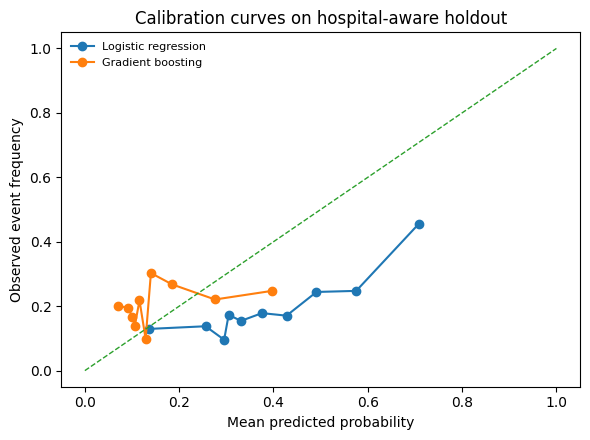

In [ ]:
# ============================================================
# 19) Calibration plots
# ============================================================
from sklearn.calibration import calibration_curve

def plot_calibration_curve(y_true, score_dict, n_bins=10):
    plt.figure(figsize=(6, 4.5))
    for name, scores in score_dict.items():
        prob_true, prob_pred = calibration_curve(y_true, scores, n_bins=n_bins, strategy="quantile")
        plt.plot(prob_pred, prob_true, marker="o", label=name)

    plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    plt.xlabel("Mean predicted probability")
    plt.ylabel("Observed event frequency")
    plt.title("Calibration curves on hospital-aware holdout")
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()

# Use only models that output probability-like scores
prob_score_dict = {
    "Logistic regression": logit_scores_test,
    "Gradient boosting": gb_scores_test
}

plot_calibration_curve(y_test, prob_score_dict, n_bins=10)

,model,k_ratio,capture_rate
0,Age-only,0.05,0.089194
1,Age + maintenance,0.05,0.104631
2,Logistic regression,0.05,0.135506
3,Gradient boosting,0.05,0.092624
4,Age-only,0.10,0.183533
5,Age + maintenance,0.10,0.226415
6,Logistic regression,0.10,0.233276
7,Gradient boosting,0.10,0.126930
8,Age-only,0.15,0.269297
9,Age + maintenance,0.15,0.313894


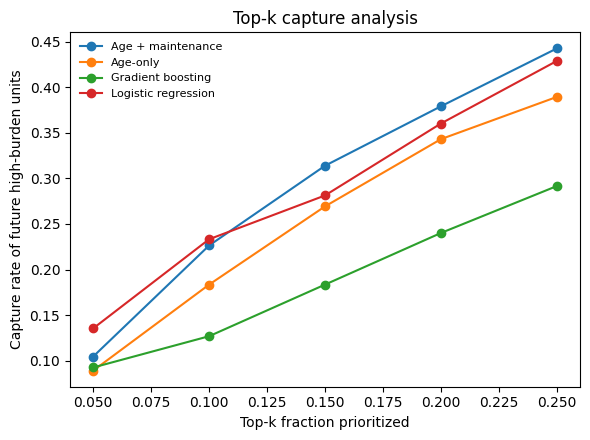

In [ ]:
# ============================================================
# 20) Top-k capture analysis
# ============================================================
k_grid = [0.05, 0.10, 0.15, 0.20, 0.25]

rows = []
for k in k_grid:
    for name, scores in score_dict.items():
        rows.append({
            "model": name,
            "k_ratio": k,
            "capture_rate": top_k_capture_rate(y_test, scores, k_ratio=k)
        })

topk_df = pd.DataFrame(rows)
display(topk_df)

plt.figure(figsize=(6, 4.5))
for model_name, tmp in topk_df.groupby("model"):
    plt.plot(tmp["k_ratio"], tmp["capture_rate"], marker="o", label=model_name)

plt.xlabel("Top-k fraction prioritized")
plt.ylabel("Capture rate of future high-burden units")
plt.title("Top-k capture analysis")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 21) Detailed decision comparison
# ============================================================
def positive_capture_among_replaced(actions, y_true):
    actions = np.asarray(actions)
    y_true = np.asarray(y_true)
    replaced = actions == "replace"
    if replaced.sum() == 0:
        return np.nan
    return y_true[replaced].mean()

def action_rate(actions, action_name):
    actions = np.asarray(actions)
    return np.mean(actions == action_name)

decision_detailed_summary = pd.DataFrame([
    {
        "rule": "Logistic threshold",
        "avg_loss": average_loss(test_df_decision["action_logit_thr"], y_test),
        "keep_rate": action_rate(test_df_decision["action_logit_thr"], "keep"),
        "replace_rate": action_rate(test_df_decision["action_logit_thr"], "replace"),
        "positive_capture_among_replaced": positive_capture_among_replaced(
            test_df_decision["action_logit_thr"], y_test
        )
    },
    {
        "rule": "Gradient boosting threshold",
        "avg_loss": average_loss(test_df_decision["action_gb_thr"], y_test),
        "keep_rate": action_rate(test_df_decision["action_gb_thr"], "keep"),
        "replace_rate": action_rate(test_df_decision["action_gb_thr"], "replace"),
        "positive_capture_among_replaced": positive_capture_among_replaced(
            test_df_decision["action_gb_thr"], y_test
        )
    }
])

display(decision_detailed_summary)

,rule,avg_loss,keep_rate,replace_rate,positive_capture_among_replaced
0,Logistic threshold,0.255767,0.762621,0.237379,0.343662
1,Gradient boosting threshold,0.196322,0.990973,0.009027,0.444444


,rule,threshold,avg_loss,keep_rate,replace_rate,positive_capture_among_replaced
0,Logistic threshold,0.2,0.564560,0.078569,0.921431,0.198839
1,Gradient boosting threshold,0.2,0.276697,0.775660,0.224340,0.235469
2,Logistic threshold,0.3,0.430224,0.352056,0.647944,0.236842
3,Gradient boosting threshold,0.3,0.230759,0.897359,0.102641,0.250814
4,Logistic threshold,0.4,0.326446,0.592444,0.407556,0.277276
5,Gradient boosting threshold,0.4,0.203878,0.958877,0.041123,0.382114
6,Logistic threshold,0.5,0.255767,0.762621,0.237379,0.343662
7,Gradient boosting threshold,0.5,0.196322,0.990973,0.009027,0.444444
8,Logistic threshold,0.6,0.216048,0.883985,0.116015,0.417867
9,Gradient boosting threshold,0.6,0.195319,0.997660,0.002340,0.428571


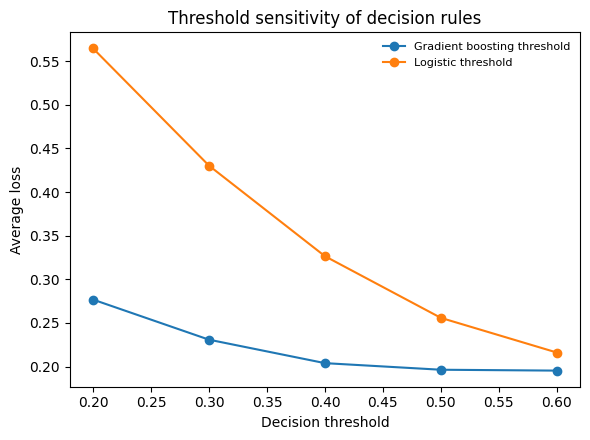

In [ ]:
# ============================================================
# 22) Threshold sensitivity analysis
# ============================================================
thresholds = [0.2, 0.3, 0.4, 0.5, 0.6]
rows = []

for thr in thresholds:
    act_logit = threshold_actions(test_df_decision["risk_logit"], thr)
    act_gb = threshold_actions(test_df_decision["risk_gb"], thr)

    rows.append({
        "rule": "Logistic threshold",
        "threshold": thr,
        "avg_loss": average_loss(act_logit, y_test),
        "keep_rate": action_rate(act_logit, "keep"),
        "replace_rate": action_rate(act_logit, "replace"),
        "positive_capture_among_replaced": positive_capture_among_replaced(act_logit, y_test)
    })

    rows.append({
        "rule": "Gradient boosting threshold",
        "threshold": thr,
        "avg_loss": average_loss(act_gb, y_test),
        "keep_rate": action_rate(act_gb, "keep"),
        "replace_rate": action_rate(act_gb, "replace"),
        "positive_capture_among_replaced": positive_capture_among_replaced(act_gb, y_test)
    })

decision_threshold_sensitivity = pd.DataFrame(rows)
display(decision_threshold_sensitivity)

plt.figure(figsize=(6, 4.5))
for rule_name, tmp in decision_threshold_sensitivity.groupby("rule"):
    plt.plot(tmp["threshold"], tmp["avg_loss"], marker="o", label=rule_name)

plt.xlabel("Decision threshold")
plt.ylabel("Average loss")
plt.title("Threshold sensitivity of decision rules")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 23) Scenario-based decision analysis
# ============================================================
scenario_grid = [
    {"scenario": "baseline", "inspect_cost": 0.20, "replace_cost": 0.60, "miss_penalty": 1.00},
    {"scenario": "lower_replace_cost", "inspect_cost": 0.20, "replace_cost": 0.40, "miss_penalty": 1.00},
    {"scenario": "high_miss_penalty", "inspect_cost": 0.20, "replace_cost": 0.60, "miss_penalty": 2.00},
    {"scenario": "balanced_intervention", "inspect_cost": 0.15, "replace_cost": 0.40, "miss_penalty": 1.50},
]

rows = []

for sc in scenario_grid:
    actions = []
    for r in logit_scores_test:
        losses, action = posterior_expected_loss_from_risk(
            r,
            inspect_cost=sc["inspect_cost"],
            replace_cost=sc["replace_cost"],
            miss_penalty=sc["miss_penalty"]
        )
        actions.append(action)

    rows.append({
        "scenario": sc["scenario"],
        "inspect_cost": sc["inspect_cost"],
        "replace_cost": sc["replace_cost"],
        "miss_penalty": sc["miss_penalty"],
        "keep_rate": np.mean(np.array(actions) == "keep"),
        "inspect_rate": np.mean(np.array(actions) == "inspect"),
        "replace_rate": np.mean(np.array(actions) == "replace"),
    })

scenario_actions_df = pd.DataFrame(rows)
display(scenario_actions_df)

,scenario,inspect_cost,replace_cost,miss_penalty,keep_rate,inspect_rate,replace_rate
0,baseline,0.20,0.6,1.0,0.174524,0.825476,0.000000
1,lower_replace_cost,0.20,0.4,1.0,0.174524,0.812772,0.012705
2,high_miss_penalty,0.20,0.6,2.0,0.055500,0.931795,0.012705
3,balanced_intervention,0.15,0.4,1.5,0.055500,0.879973,0.064527


In [ ]:
# ============================================================
# 24) Leave-one-hospital-out evaluation for major hospitals
# ============================================================
major_hospitals = hospital_stats[hospital_stats["n"] >= 300]["hospital_hash"].tolist()

loho_rows = []

for hosp in major_hospitals:
    tr = df[df["hospital_hash"] != hosp].copy()
    te = df[df["hospital_hash"] == hosp].copy()

    if te[target_col].nunique() < 2:
        continue

    X_tr = tr[numeric_features + categorical_features].copy()
    y_tr = tr[target_col].astype(int).values
    X_te = te[numeric_features + categorical_features].copy()
    y_te = te[target_col].astype(int).values

    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=2000, class_weight="balanced"))
    ])

    model.fit(X_tr, y_tr)
    scores = model.predict_proba(X_te)[:, 1]

    loho_rows.append({
        "hospital_hash": hosp,
        "n_test": len(te),
        "outcome_rate": te[target_col].mean(),
        "auroc": roc_auc_score(y_te, scores),
        "auprc": average_precision_score(y_te, scores),
        "brier": brier_score_loss(y_te, scores)
    })

loho_df = pd.DataFrame(loho_rows)
display(loho_df)

,hospital_hash,n_test,outcome_rate,auroc,auprc,brier
0,h_31b6b276b9e0,1119,0.248436,0.629676,0.408993,0.216945
1,h_e176ae8ff561,975,0.200000,0.639665,0.338417,0.206365
2,h_9e0082cc03bb,897,0.122631,0.501092,0.151712,0.197205
3,h_f3391264376f,735,0.187755,0.605892,0.283849,0.238707
4,h_fc448b9753aa,700,0.128571,0.510073,0.146938,0.255153
5,h_db26b7f2fbc8,650,0.312308,0.611791,0.424942,0.255287
6,h_b052b2239a62,649,0.315871,0.622352,0.493576,0.229848
7,h_ed200b674eda,638,0.101881,0.467069,0.105034,0.181856
8,h_d90e01eb9931,629,0.494436,0.580310,0.589804,0.271772
9,h_12dcdfb79130,492,0.382114,0.564521,0.463459,0.307525


In [33]:
# ============================================================
# 25) Final PyMC model: hierarchical Bayesian latent deterioration risk model
# ============================================================
RUN_BAYESIAN_MODEL = True

if RUN_BAYESIAN_MODEL:
    import pymc as pm
    import arviz as az

    # ----------------------------
    # Training data
    # ----------------------------
    bayes_train = train_df.copy()
    bayes_test = test_df.copy()

    # Keep only the core features for a stable first final model
    core_num_cols = ["age_at_year", "cm_count", "total_downtime_hours"]
    for c in core_num_cols:
        bayes_train[c] = bayes_train[c].fillna(bayes_train[c].median())
        bayes_test[c] = bayes_test[c].fillna(bayes_train[c].median())

    # log-transform downtime for stability
    bayes_train["log_total_downtime_hours"] = np.log1p(bayes_train["total_downtime_hours"])
    bayes_test["log_total_downtime_hours"] = np.log1p(bayes_test["total_downtime_hours"])

    # Standardize numeric predictors using training stats
    scale_cols = ["age_at_year", "cm_count", "log_total_downtime_hours"]
    scaler_stats = {}
    for c in scale_cols:
        mu = bayes_train[c].mean()
        sd = bayes_train[c].std()
        if sd == 0 or pd.isna(sd):
            sd = 1.0
        scaler_stats[c] = (mu, sd)
        bayes_train[c + "_z"] = (bayes_train[c] - mu) / sd
        bayes_test[c + "_z"] = (bayes_test[c] - mu) / sd

    # ----------------------------
    # Encodings
    # ----------------------------
    hospital_cats = pd.Categorical(bayes_train["hospital_hash"])
    brand_cats = pd.Categorical(bayes_train["brand_hash"])

    hospital_map = {cat: i for i, cat in enumerate(hospital_cats.categories)}
    brand_map = {cat: i for i, cat in enumerate(brand_cats.categories)}

    bayes_train["hospital_idx"] = bayes_train["hospital_hash"].map(hospital_map)
    bayes_train["brand_idx"] = bayes_train["brand_hash"].map(brand_map)

    # For unseen hospitals/brands in test, use -1 and handle separately
    bayes_test["hospital_idx"] = bayes_test["hospital_hash"].map(hospital_map).fillna(-1).astype(int)
    bayes_test["brand_idx"] = bayes_test["brand_hash"].map(brand_map).fillna(-1).astype(int)

    # train arrays
    age_tr = bayes_train["age_at_year_z"].values
    cm_tr = bayes_train["cm_count_z"].values
    dt_tr = bayes_train["log_total_downtime_hours_z"].values
    h_tr = bayes_train["hospital_idx"].values.astype(int)
    b_tr = bayes_train["brand_idx"].values.astype(int)
    y_tr = bayes_train[target_col].astype(int).values

    n_hosp = bayes_train["hospital_idx"].nunique()
    n_brand = bayes_train["brand_idx"].nunique()

    with pm.Model() as final_bayes_model:

      mu_h = pm.Normal("mu_h", mu=0.0, sigma=1.0)
      sigma_h = pm.HalfNormal("sigma_h", sigma=1.0)
      mu_b = pm.Normal("mu_b", mu=0.0, sigma=1.0)
      sigma_b = pm.HalfNormal("sigma_b", sigma=1.0)

      alpha_h = pm.Normal("alpha_h", mu=mu_h, sigma=sigma_h, shape=n_hosp)
      alpha_b = pm.Normal("alpha_b", mu=mu_b, sigma=sigma_b, shape=n_brand)

      beta_age = pm.Normal("beta_age", mu=0.0, sigma=0.5)
      beta_cm  = pm.Normal("beta_cm",  mu=0.0, sigma=0.5)
      beta_dt  = pm.Normal("beta_dt",  mu=0.0, sigma=0.5)

      eta = (
          alpha_h[h_tr]
          + alpha_b[b_tr]
          + beta_age * age_tr
          + beta_cm  * cm_tr
          + beta_dt  * dt_tr
      )

      # latent deterioration score only as a deterministic interpretation layer
      z_latent = pm.Deterministic("z_latent", eta)

      y_obs = pm.Bernoulli("y_obs", logit_p=eta, observed=y_tr)

      idata_final = pm.sample(
          draws=2000,
          tune=2000,
          chains=4,
          target_accept=0.97,
          random_seed=42
      )

    display(az.summary(
    idata_final,
    var_names=["mu_h", "sigma_h", "mu_b", "sigma_b", "beta_age", "beta_cm", "beta_dt"],
    round_to=3
    ))
else:
    print("RUN_BAYESIAN_MODEL is False.")

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


KeyError: 'var names: "[\'gamma0\' \'gamma_z\'] are not present" in dataset'

In [34]:
print(az.rhat(idata_final, var_names=["mu_h", "sigma_h", "mu_b", "sigma_b", "beta_age", "beta_cm", "beta_dt"]))
print(az.ess(idata_final, var_names=["mu_h", "sigma_h", "mu_b", "sigma_b", "beta_age", "beta_cm", "beta_dt"]))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_h,-0.660,0.697,-1.948,0.607,0.111,0.048,39.561,142.605,1.089
sigma_h,0.874,0.125,0.665,1.117,0.002,0.002,3770.159,4519.039,1.000
mu_b,-0.644,0.700,-1.900,0.683,0.113,0.049,38.665,138.829,1.090
sigma_b,0.307,0.098,0.142,0.490,0.003,0.002,1138.143,2478.018,1.001
beta_age,0.021,0.033,-0.040,0.083,0.001,0.000,4075.147,4849.973,1.001
beta_cm,0.313,0.030,0.260,0.375,0.000,0.000,4019.341,4585.968,1.000
beta_dt,0.156,0.030,0.103,0.213,0.000,0.000,3879.967,5046.532,1.001


<xarray.Dataset> Size: 56B
Dimensions:   ()
Data variables:
    mu_h      float64 8B 1.089
    sigma_h   float64 8B 1.0
    mu_b      float64 8B 1.09
    sigma_b   float64 8B 1.001
    beta_age  float64 8B 1.001
    beta_cm   float64 8B 1.0
    beta_dt   float64 8B 1.001
Attributes:
    created_at:                 2026-04-17T16:17:36.221276+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              2082.359419107437
    tuning_steps:               2000
<xarray.Dataset> Size: 56B
Dimensions:   ()
Data variables:
    mu_h      float64 8B 39.56
    sigma_h   float64 8B 3.77e+03
    mu_b      float64 8B 38.66
    sigma_b   float64 8B 1.138e+03
    beta_age  float64 8B 4.075e+03
    beta_cm   float64 8B 4.019e+03
    beta_dt   float64 8B 3.88e+03
Attributes:
    created_at:                 2026-04-17T16:17:36.221276+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
 

In [35]:
with pm.Model() as final_bayes_model:

    mu_h = pm.Normal("mu_h", mu=0.0, sigma=1.0)
    sigma_h = pm.HalfNormal("sigma_h", sigma=1.0)
    alpha_h = pm.Normal("alpha_h", mu=mu_h, sigma=sigma_h, shape=n_hosp)

    beta_age = pm.Normal("beta_age", mu=0.0, sigma=0.5)
    beta_cm  = pm.Normal("beta_cm",  mu=0.0, sigma=0.5)
    beta_dt  = pm.Normal("beta_dt",  mu=0.0, sigma=0.5)

    eta = (
        alpha_h[h_tr]
        + beta_age * age_tr
        + beta_cm  * cm_tr
        + beta_dt  * dt_tr
    )

    z_latent = pm.Deterministic("z_latent", eta)

    y_obs = pm.Bernoulli("y_obs", logit_p=eta, observed=y_tr)

    idata_final = pm.sample(
        draws=2000,
        tune=2000,
        chains=4,
        target_accept=0.97,
        random_seed=42
    )

    display(az.summary(
    idata_final,
    var_names=["mu_h", "sigma_h", "beta_age", "beta_cm", "beta_dt"],
    round_to=3
    ))

Output()

KeyError: 'var names: "[\'mu_b\' \'sigma_b\'] are not present" in dataset'

In [39]:
display(az.summary(
   idata_final,
   var_names=["mu_h", "sigma_h", "beta_age", "beta_cm", "beta_dt"],
   round_to=3
))

print(az.rhat(idata_final, var_names=["mu_h", "sigma_h", "beta_age", "beta_cm", "beta_dt"]))

print(az.ess(idata_final, var_names=["mu_h", "sigma_h", "beta_age", "beta_cm", "beta_dt"]))

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_h,-1.210,0.152,-1.493,-0.921,0.001,0.002,10670.166,5900.137,1.001
sigma_h,0.885,0.127,0.666,1.131,0.002,0.002,7091.011,5736.182,1.000
beta_age,-0.003,0.024,-0.048,0.043,0.000,0.000,9994.997,6329.036,1.001
beta_cm,0.313,0.031,0.253,0.368,0.000,0.000,7315.575,6304.181,1.001
beta_dt,0.160,0.030,0.103,0.215,0.000,0.000,7468.201,6607.260,1.000


<xarray.Dataset> Size: 40B
Dimensions:   ()
Data variables:
    mu_h      float64 8B 1.001
    sigma_h   float64 8B 1.0
    beta_age  float64 8B 1.001
    beta_cm   float64 8B 1.001
    beta_dt   float64 8B 1.0
Attributes:
    created_at:                 2026-04-17T16:39:54.445875+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              539.1923995018005
    tuning_steps:               2000
<xarray.Dataset> Size: 40B
Dimensions:   ()
Data variables:
    mu_h      float64 8B 1.067e+04
    sigma_h   float64 8B 7.091e+03
    beta_age  float64 8B 9.995e+03
    beta_cm   float64 8B 7.316e+03
    beta_dt   float64 8B 7.468e+03
Attributes:
    created_at:                 2026-04-17T16:39:54.445875+00:00
    arviz_version:              0.22.0
    inference_library:          pymc
    inference_library_version:  5.28.4
    sampling_time:              539.1923995018005
    tuning_steps:               2

In [47]:
# ============================================================
# 26) Posterior predictive risk on test set
#    (simplified hierarchical Bayesian model)
# ============================================================
posterior = idata_final.posterior

# Posterior means for practical prediction
mu_h_mean = posterior["mu_h"].mean(dim=("chain", "draw")).item()
alpha_h_mean = posterior["alpha_h"].mean(dim=("chain", "draw")).values

beta_age_mean = posterior["beta_age"].mean(dim=("chain", "draw")).item()
beta_cm_mean = posterior["beta_cm"].mean(dim=("chain", "draw")).item()
beta_dt_mean = posterior["beta_dt"].mean(dim=("chain", "draw")).item()

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Test predictors
age_te = bayes_test["age_at_year_z"].values
cm_te = bayes_test["cm_count_z"].values
dt_te = bayes_test["log_total_downtime_hours_z"].values
h_te = bayes_test["hospital_idx"].values.astype(int)

# Handle unseen hospitals using the posterior mean of mu_h
h_effect_te = np.where(h_te >= 0, alpha_h_mean[h_te], mu_h_mean)

# Linear predictor
eta_te = h_effect_te + beta_age_mean * age_te + beta_cm_mean * cm_te + beta_dt_mean * dt_te

# Posterior predictive risk proxy
bayes_risk_test = sigmoid(eta_te)

bayes_results = classification_summary(
    y_true=y_test,
    scores=bayes_risk_test,
    name="Hierarchical Bayesian latent deterioration model"
)

bayes_results

{'model': 'Hierarchical Bayesian latent deterioration model',
 'auroc': np.float64(0.6144501889071876),
 'auprc': np.float64(0.3198815294757624),
 'brier': np.float64(0.14893380452217922),
 'top10_capture': np.float64(0.20754716981132076)}

In [48]:
# ============================================================
# 27) Add Bayesian model to benchmark comparison
# ============================================================
results_df_final = pd.DataFrame([
    age_results,
    am_results,
    logit_results,
    gb_results,
    bayes_results
]).sort_values("auprc", ascending=False)

display(results_df_final)

,model,auroc,auprc,brier,top10_capture
2,Logistic regression,0.646719,0.342109,0.191822,0.233276
1,Age + maintenance heuristic,0.674192,0.322373,0.165280,0.226415
4,Hierarchical Bayesian latent deterioration model,0.614450,0.319882,0.148934,0.207547
0,Age-only heuristic,0.629607,0.284081,0.165412,0.183533
3,Gradient boosting,0.537677,0.239495,0.161686,0.126930


In [66]:
score_dict_final = {
    "Age-only": age_score_test,
    "Age + maintenance": score_am_test,
    "Logistic regression": logit_scores_test,
    "Gradient boosting": gb_scores_test,
    "Bayesian latent model": bayes_risk_test
}

prob_score_dict_final = {
    "Logistic regression": logit_scores_test,
    "Gradient boosting": gb_scores_test,
    "Bayesian latent model": bayes_risk_test
}

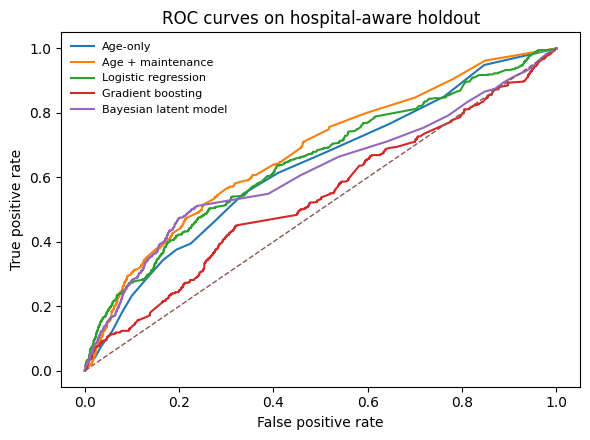

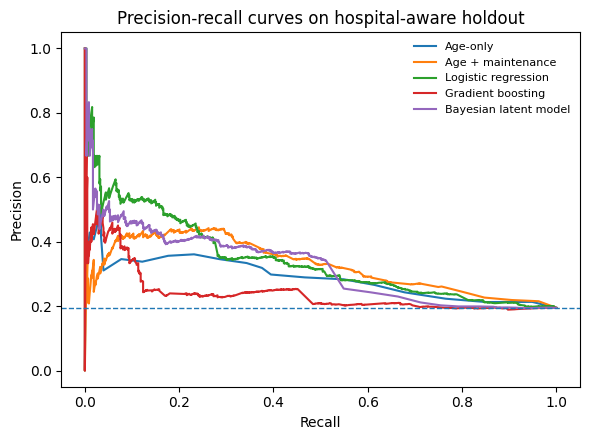

In [67]:
# ROC + PR updated
plt.figure(figsize=(6, 4.5))
for name, scores in score_dict_final.items():
    fpr, tpr, _ = roc_curve(y_test, scores)
    plt.plot(fpr, tpr, label=name)
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC curves on hospital-aware holdout")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4.5))
for name, scores in score_dict_final.items():
    precision, recall, _ = precision_recall_curve(y_test, scores)
    plt.plot(recall, precision, label=name)
plt.axhline(y=y_test.mean(), linestyle="--", linewidth=1)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-recall curves on hospital-aware holdout")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

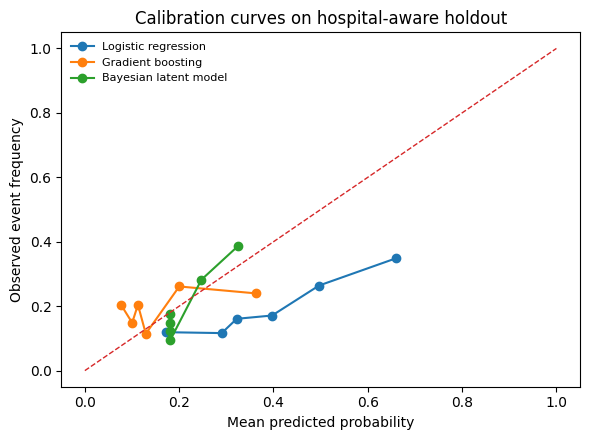

In [68]:
# Calibration updated
plot_calibration_curve(y_test, prob_score_dict_final, n_bins=6)

,model,k_ratio,capture_rate
0,Age-only,0.05,0.089194
1,Age + maintenance,0.05,0.104631
2,Logistic regression,0.05,0.135506
3,Gradient boosting,0.05,0.092624
4,Bayesian latent model,0.05,0.118353
5,Age-only,0.10,0.183533
6,Age + maintenance,0.10,0.226415
7,Logistic regression,0.10,0.233276
8,Gradient boosting,0.10,0.126930
9,Bayesian latent model,0.10,0.207547


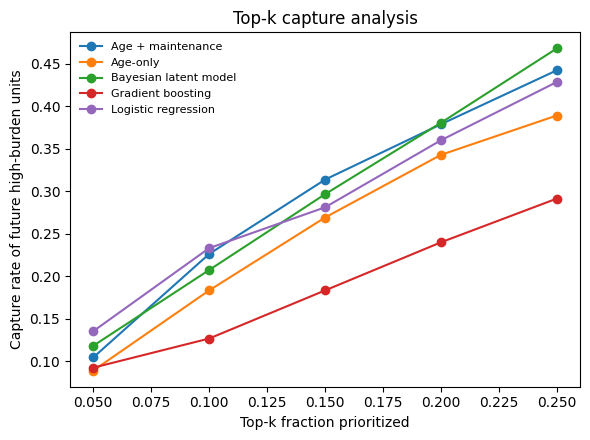

In [69]:
# Top-k updated
k_grid = [0.05, 0.10, 0.15, 0.20, 0.25]

rows = []
for k in k_grid:
    for name, scores in score_dict_final.items():
        rows.append({
            "model": name,
            "k_ratio": k,
            "capture_rate": top_k_capture_rate(y_test, scores, k_ratio=k)
        })

topk_df_final = pd.DataFrame(rows)
display(topk_df_final)

plt.figure(figsize=(6, 4.5))
for model_name, tmp in topk_df_final.groupby("model"):
    plt.plot(tmp["k_ratio"], tmp["capture_rate"], marker="o", label=model_name)

plt.xlabel("Top-k fraction prioritized")
plt.ylabel("Capture rate of future high-burden units")
plt.title("Top-k capture analysis")
plt.legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

In [70]:
# ============================================================
# 29) Decision layer using Bayesian posterior risk proxy
# ============================================================
bayes_actions = []
for r in bayes_risk_test:
    losses, action = posterior_expected_loss_from_risk(
        r,
        inspect_cost=0.20,
        replace_cost=0.40,
        miss_penalty=1.50
    )
    bayes_actions.append(action)

bayes_decision_summary = pd.DataFrame([{
    "rule": "Bayesian decision rule",
    "avg_loss": average_loss(bayes_actions, y_test, inspect_cost=0.20, replace_cost=0.40, miss_penalty=1.50),
    "keep_rate": action_rate(bayes_actions, "keep"),
    "inspect_rate": action_rate(bayes_actions, "inspect"),
    "replace_rate": action_rate(bayes_actions, "replace"),
    "positive_capture_among_replaced": positive_capture_among_replaced(bayes_actions, y_test)
}])

display(bayes_decision_summary)

,rule,avg_loss,keep_rate,inspect_rate,replace_rate,positive_capture_among_replaced
0,Bayesian decision rule,0.272927,0.0,0.998328,0.001672,0.8


In [71]:
# ============================================================
# 30) Additional loss scenarios for the Bayesian decision rule
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def positive_capture_among_action(actions, y_true, action_name="replace"):
    actions = np.asarray(actions)
    y_true = np.asarray(y_true)
    mask = actions == action_name
    if mask.sum() == 0:
        return np.nan
    return y_true[mask].mean()

def action_rate(actions, action_name):
    actions = np.asarray(actions)
    return np.mean(actions == action_name)

# Three additional scenarios
bayes_scenarios = [
    {
        "scenario": "inspection_favored",
        "inspect_cost": 0.10,
        "replace_cost": 0.60,
        "miss_penalty": 1.20
    },
    {
        "scenario": "balanced_intervention",
        "inspect_cost": 0.20,
        "replace_cost": 0.35,
        "miss_penalty": 1.50
    },
    {
        "scenario": "replacement_favored_high_miss",
        "inspect_cost": 0.25,
        "replace_cost": 0.30,
        "miss_penalty": 2.00
    }
]

scenario_rows = []

for sc in bayes_scenarios:
    actions = []
    for r in bayes_risk_test:
        losses, action = posterior_expected_loss_from_risk(
            r,
            inspect_cost=sc["inspect_cost"],
            replace_cost=sc["replace_cost"],
            miss_penalty=sc["miss_penalty"]
        )
        actions.append(action)

    scenario_rows.append({
        "scenario": sc["scenario"],
        "inspect_cost": sc["inspect_cost"],
        "replace_cost": sc["replace_cost"],
        "miss_penalty": sc["miss_penalty"],
        "avg_loss": average_loss(
            actions,
            y_test,
            inspect_cost=sc["inspect_cost"],
            replace_cost=sc["replace_cost"],
            miss_penalty=sc["miss_penalty"]
        ),
        "keep_rate": action_rate(actions, "keep"),
        "inspect_rate": action_rate(actions, "inspect"),
        "replace_rate": action_rate(actions, "replace"),
        "positive_capture_among_inspected": positive_capture_among_action(actions, y_test, "inspect"),
        "positive_capture_among_replaced": positive_capture_among_action(actions, y_test, "replace")
    })

bayes_scenarios_df = pd.DataFrame(scenario_rows)
display(bayes_scenarios_df)

,scenario,inspect_cost,replace_cost,miss_penalty,avg_loss,keep_rate,inspect_rate,replace_rate,positive_capture_among_inspected,positive_capture_among_replaced
0,inspection_favored,0.10,0.60,1.2,0.158475,0.0,1.000000,0.000000,0.194918,NaN
1,balanced_intervention,0.20,0.35,1.5,0.272267,0.0,0.981277,0.018723,0.188756,0.517857
2,replacement_favored_high_miss,0.25,0.30,2.0,0.300000,0.0,0.000000,1.000000,NaN,0.194918


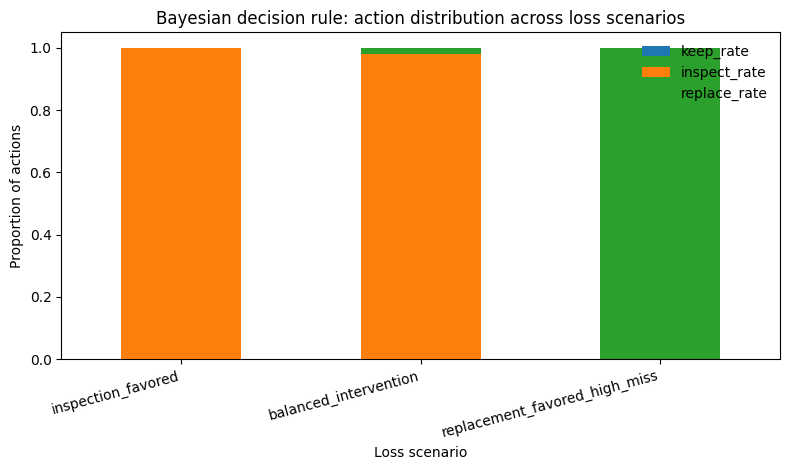

In [72]:
# ============================================================
# 31) Stacked bar plot: action distribution by Bayesian scenario
# ============================================================
plot_df = bayes_scenarios_df.copy()
plot_df = plot_df.set_index("scenario")[["keep_rate", "inspect_rate", "replace_rate"]]

ax = plot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 4.8)
)

ax.set_ylabel("Proportion of actions")
ax.set_xlabel("Loss scenario")
ax.set_title("Bayesian decision rule: action distribution across loss scenarios")
ax.legend(frameon=False)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

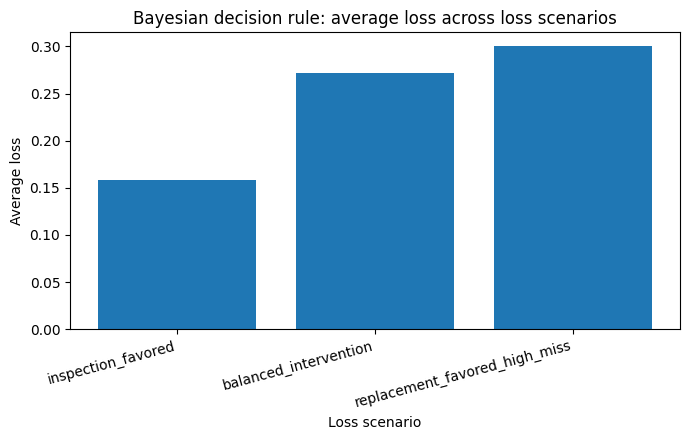

In [73]:
# ============================================================
# 32) Average loss by Bayesian scenario
# ============================================================
plt.figure(figsize=(7, 4.5))
plt.bar(bayes_scenarios_df["scenario"], bayes_scenarios_df["avg_loss"])
plt.ylabel("Average loss")
plt.xlabel("Loss scenario")
plt.title("Bayesian decision rule: average loss across loss scenarios")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

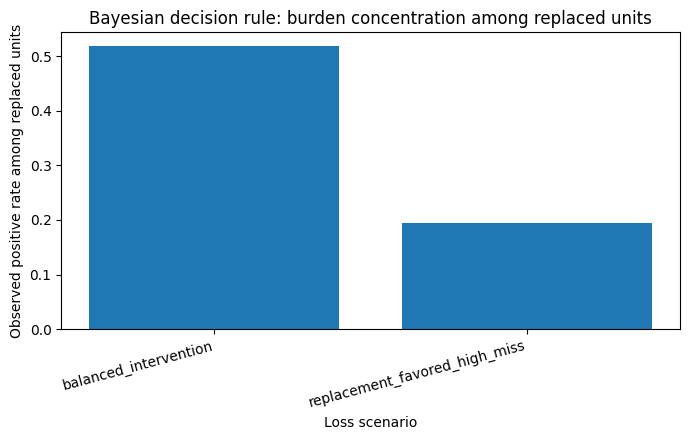

In [74]:
# ============================================================
# 33) Positive capture among replaced units by scenario
# ============================================================
tmp = bayes_scenarios_df.copy()

plt.figure(figsize=(7, 4.5))
plt.bar(tmp["scenario"], tmp["positive_capture_among_replaced"])
plt.ylabel("Observed positive rate among replaced units")
plt.xlabel("Loss scenario")
plt.title("Bayesian decision rule: burden concentration among replaced units")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()

In [76]:
score_dict_final = {
    "Age-only": age_score_test,
    "Age + maintenance": score_am_test,
    "Logistic regression": logit_scores_test,
    "Gradient boosting": gb_scores_test,
    "Bayesian latent model": bayes_risk_test
}

In [77]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, precision_recall_curve

def make_roc_pr_figure(score_dict_final, y_test, output_path="figure_roc_pr_benchmarks.png"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

    # ROC
    for name, scores in score_dict_final.items():
        fpr, tpr, _ = roc_curve(y_test, scores)
        axes[0].plot(fpr, tpr, label=name)
    axes[0].plot([0, 1], [0, 1], linestyle="--", linewidth=1)
    axes[0].set_xlabel("False positive rate")
    axes[0].set_ylabel("True positive rate")
    axes[0].set_title("(a) ROC curves")

    # PR
    for name, scores in score_dict_final.items():
        precision, recall, _ = precision_recall_curve(y_test, scores)
        axes[1].plot(recall, precision, label=name)
    axes[1].axhline(y=y_test.mean(), linestyle="--", linewidth=1)
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_title("(b) Precision-recall curves")

    handles, labels = axes[1].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=3, frameon=False)
    plt.tight_layout(rect=[0, 0.08, 1, 1])
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

In [78]:
def make_topk_figure(topk_df_final, output_path="figure_topk_capture.png"):
    plt.figure(figsize=(7, 4.8))
    for model_name, tmp in topk_df_final.groupby("model"):
        plt.plot(tmp["k_ratio"], tmp["capture_rate"], marker="o", label=model_name)

    plt.xlabel("Top-k fraction prioritized")
    plt.ylabel("Capture rate of future high-burden units")
    plt.title("Top-k capture analysis")
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

In [79]:
def make_bayes_action_scenario_figure(bayes_scenarios_df, output_path="figure_bayes_action_scenarios.png"):
    plot_df = bayes_scenarios_df.set_index("scenario")[["keep_rate", "inspect_rate", "replace_rate"]]

    ax = plot_df.plot(kind="bar", stacked=True, figsize=(7.5, 4.8))
    ax.set_ylabel("Proportion of actions")
    ax.set_xlabel("Loss scenario")
    ax.set_title("Bayesian decision rule across loss scenarios")
    ax.legend(frameon=False)
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

In [ ]:
# 1) definir funções
# (cole e execute os blocos das funções)

# 2) gerar figuras
make_roc_pr_figure(score_dict_final, y_test)
make_topk_figure(topk_df_final)
make_bayes_action_scenario_figure(bayes_scenarios_df)

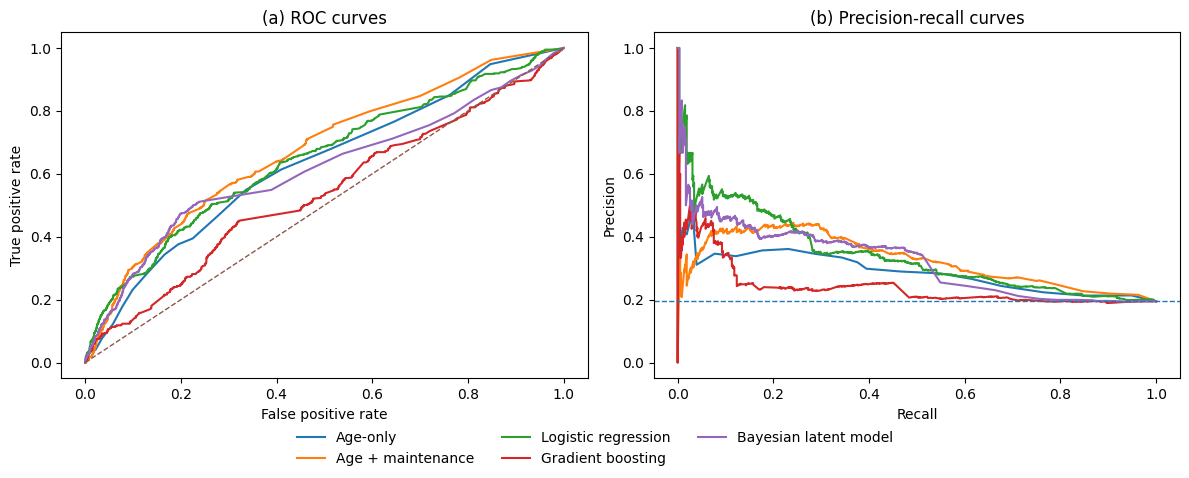

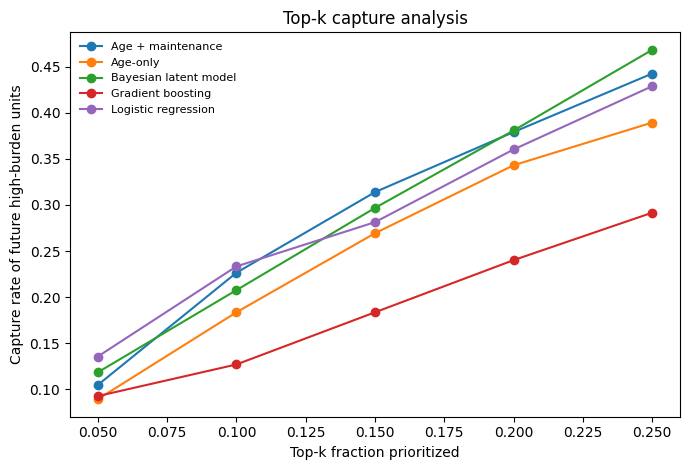

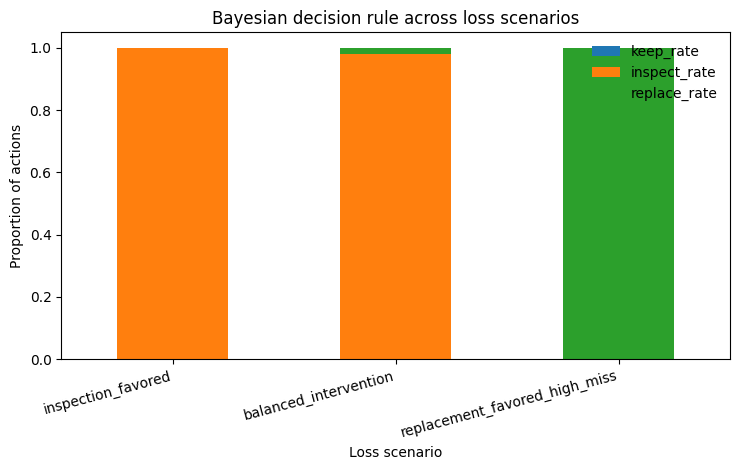

In [80]:
make_roc_pr_figure(score_dict_final, y_test)
make_topk_figure(topk_df_final)
make_bayes_action_scenario_figure(bayes_scenarios_df)

In [81]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def make_bayes_action_scenario_figure_pretty(
    bayes_scenarios_df,
    output_path="figure_bayes_action_scenarios_pretty.png"
):
    # Copy and relabel scenarios for cleaner display
    plot_df = bayes_scenarios_df.copy()

    scenario_label_map = {
        "inspection_favored": "Inspection-\nfavored",
        "balanced_intervention": "Balanced\nintervention",
        "replacement_favored_high_miss": "Replacement-\nfavored\nhigh-miss"
    }

    plot_df["scenario_label"] = plot_df["scenario"].map(scenario_label_map).fillna(plot_df["scenario"])

    plot_df = plot_df.set_index("scenario_label")[["keep_rate", "inspect_rate", "replace_rate"]]

    fig, ax = plt.subplots(figsize=(8.5, 5.2))

    bottom = np.zeros(len(plot_df))
    colors = {
        "keep_rate": "#4C78A8",
        "inspect_rate": "#F58518",
        "replace_rate": "#54A24B"
    }
    labels = {
        "keep_rate": "Keep",
        "inspect_rate": "Inspect",
        "replace_rate": "Replace"
    }

    for col in ["keep_rate", "inspect_rate", "replace_rate"]:
        values = plot_df[col].values
        bars = ax.bar(
            plot_df.index,
            values,
            bottom=bottom,
            label=labels[col],
            color=colors[col],
            edgecolor="black",
            linewidth=0.5,
            width=0.58
        )

        # Add percentage labels only when the segment is large enough
        for bar, val, btm in zip(bars, values, bottom):
            if val >= 0.06:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    btm + val / 2,
                    f"{val*100:.1f}%",
                    ha="center",
                    va="center",
                    fontsize=9
                )

        bottom += values

    ax.set_ylim(0, 1.02)
    ax.set_ylabel("Proportion of actions")
    ax.set_xlabel("Loss scenario")
    ax.set_title("Bayesian decision rule across loss scenarios")

    # Format y-axis as percentages
    yticks = np.linspace(0, 1, 6)
    ax.set_yticks(yticks)
    ax.set_yticklabels([f"{int(y*100)}%" for y in yticks])

    # Move legend outside
    ax.legend(
        frameon=False,
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0),
        borderaxespad=0
    )

    # Light horizontal grid only
    ax.grid(axis="y", alpha=0.25)
    ax.set_axisbelow(True)

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

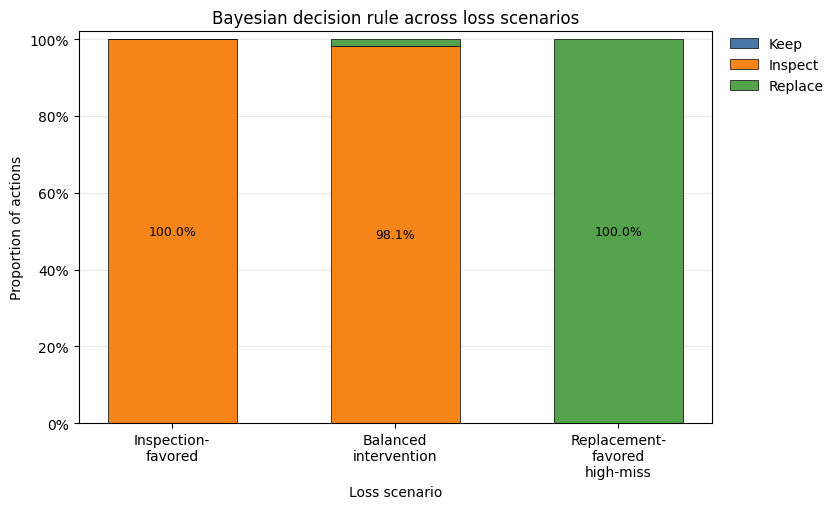

In [82]:
make_bayes_action_scenario_figure_pretty(bayes_scenarios_df)

In [83]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def make_bayes_action_scenario_heatmap(
    bayes_scenarios_df,
    output_path="figure_bayes_action_scenarios_heatmap.png"
):
    plot_df = bayes_scenarios_df.copy()

    scenario_label_map = {
        "inspection_favored": "Inspection-favored",
        "balanced_intervention": "Balanced intervention",
        "replacement_favored_high_miss": "Replacement-favored high-miss"
    }

    plot_df["scenario_label"] = plot_df["scenario"].map(scenario_label_map).fillna(plot_df["scenario"])

    heatmap_df = plot_df.set_index("scenario_label")[["keep_rate", "inspect_rate", "replace_rate"]]
    heatmap_df.columns = ["Keep", "Inspect", "Replace"]

    fig, ax = plt.subplots(figsize=(7.5, 3.8))

    im = ax.imshow(heatmap_df.values, aspect="auto")

    # Axis labels
    ax.set_xticks(np.arange(len(heatmap_df.columns)))
    ax.set_xticklabels(heatmap_df.columns)
    ax.set_yticks(np.arange(len(heatmap_df.index)))
    ax.set_yticklabels(heatmap_df.index)

    ax.set_title("Bayesian decision rule across loss scenarios")
    ax.set_xlabel("Action")
    ax.set_ylabel("Loss scenario")

    # Add text annotations
    for i in range(heatmap_df.shape[0]):
        for j in range(heatmap_df.shape[1]):
            value = heatmap_df.iloc[i, j]
            ax.text(
                j, i,
                f"{value*100:.1f}%",
                ha="center",
                va="center",
                fontsize=9
            )

    # Colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Proportion of actions")

    plt.tight_layout()
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()